## Data Cleaning Workflow:
<input type="checkbox" checked id="option1" name="option1" value="yes">
<label for="option1">Import necessary libraries.</label>
<br />
<input type="checkbox" checked id="option2" name="option2" value="yes">
<label for="option2">Reading dataset.</label>
<br />
<input type="checkbox" checked id="option3" name="option3" value="yes">
<label for="option3">Drop columns wich we don't need them.</label>
<br />
<input type="checkbox" checked id="option4" name="option4" value="yes">
<label for="option4">Finding Nan values (In this dataset, Address had Nan, but we droped it).</label>
<br />
<input type="checkbox" checked id="option5" name="option5" value="yes">
<label for="option5">Getting some information about dataset ( with df.info() and df.describe() ).</label>
<br />
<input type="checkbox" checked id="option6" name="option6" value="yes">
<label for="option6">Plotting price on boxplot to see how much we have outliers.</label>
<br />
<input type="checkbox" checked id="option7" name="option7" value="yes">
<label for="option7">Removing outliers and add non-outlier values to new dataset. Then save it as excel file.</label>
<br />

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl

In [2]:
df = pd.read_csv("dataset/HousePrice.csv")

In [3]:
df.head(3)

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,63,1,True,True,True,Shahran,1850000000,61666.67
1,60,1,True,True,True,Shahran,1850000000,61666.67
2,79,2,True,True,True,Pardis,550000000,18333.33


In [4]:
# We don't need "Address" and "Price(USD)" features!
df.drop(["Address","Price(USD)"],axis=1,inplace=True)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3479 entries, 0 to 3478
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Area       3479 non-null   int64
 1   Room       3479 non-null   int64
 2   Parking    3479 non-null   bool 
 3   Warehouse  3479 non-null   bool 
 4   Elevator   3479 non-null   bool 
 5   Price      3479 non-null   int64
dtypes: bool(3), int64(3)
memory usage: 91.9 KB


In [6]:
df.describe()

,Area,Room,Price
count,3.479000e+03,3479.000000,3.479000e+03
mean,8.744000e+06,2.079908,5.359023e+09
std,3.167266e+08,0.758275,8.099935e+09
min,3.000000e+01,0.000000,3.600000e+06
25%,6.900000e+01,2.000000,1.418250e+09
50%,9.000000e+01,2.000000,2.900000e+09
75%,1.200000e+02,2.000000,6.000000e+09
max,1.616000e+10,5.000000,9.240000e+10


<Axes: xlabel='Price'>

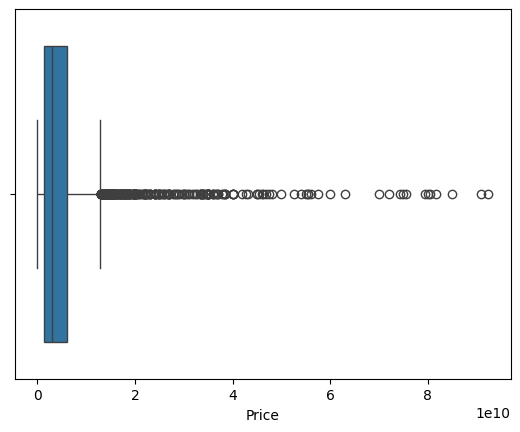

In [7]:
sns.boxplot(data=df,x="Price")

In [8]:
data = df.copy()

Q1 = data["Price"].quantile(0.25)
Q3 = data["Price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data["outlier"] = ((data["Price"] < lower_bound) | (data["Price"] > upper_bound))

data = data.loc[data["outlier"] == False]

In [9]:
data.head()

,Area,Room,Parking,Warehouse,Elevator,Price,outlier
0,63,1,True,True,True,1850000000,False
1,60,1,True,True,True,1850000000,False
2,79,2,True,True,True,550000000,False
3,95,2,True,True,True,902500000,False
4,123,2,True,True,True,7000000000,False


In [10]:
data.to_excel("data transformed/data.xlsx",index=None)